In [33]:
import pandas as pd
import numpy as np

# dfx = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/Funding flow.csv', encoding='cp1252')

dfy = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/dfy_SUBAWARD FLOW TO ENTITIES_Assistance_Subawards_2026-09-22_H20M40S39_1.csv', encoding='cp1252')
dfx = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/dfx_FUND_ORIGINS_Assistance_PrimeTransactions_2026-09-22_H20M40S34_1.csv', encoding='cp1252')
dfz = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/dfz_Assistance_PrimeAwardSummaries_2026-09-22_H20M40S30_1.csv', encoding='cp1252')
dfw = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/dfw_ACOE_12miml_TLP_Contracts_PrimeTransactions_2026-09-22_H20M40S32_1.csv', encoding='cp1252')

df = dfx.copy()

# for col in df.columns:
#     print(col)

# df

In [ ]:
'''
Next steps:
- parse by year, or standardize somehow
- for GA DNR: sub sankey with CIG permits (match using project description???)
- Also for GA DNR - state funding for budget vs. this, which is just for restoration projects

'''

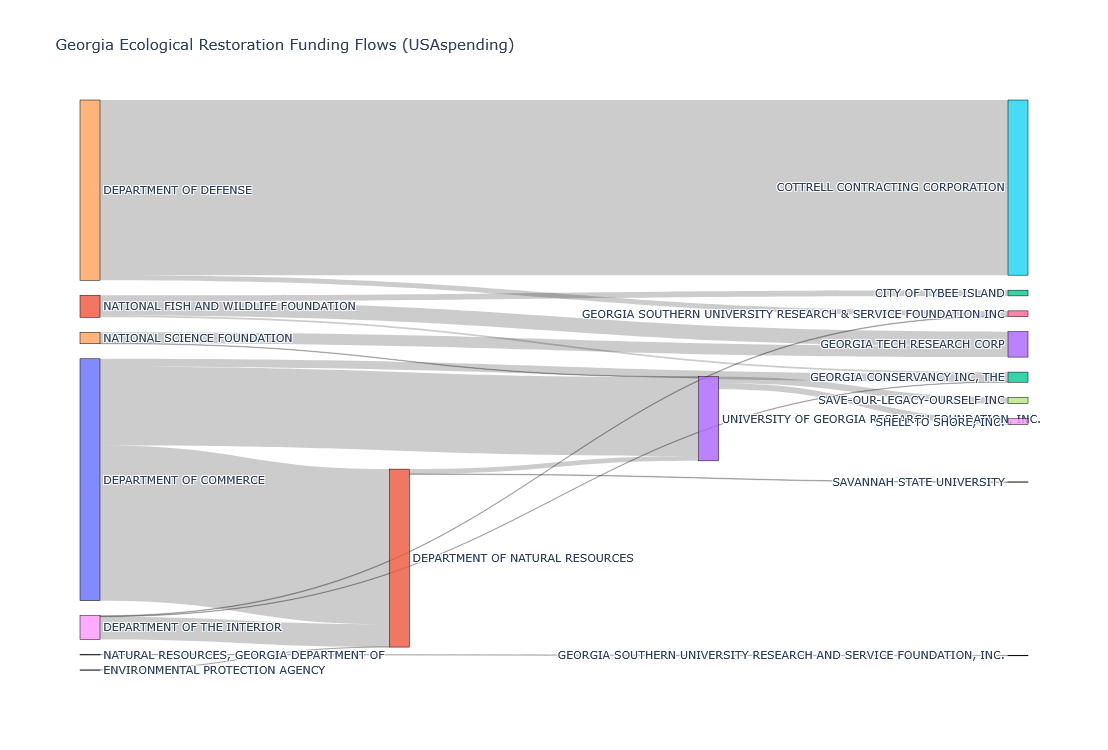

In [38]:
import pandas as pd
import plotly.graph_objects as go

# ---------------------------------------------------------
# 1. Helper Functions & Normalization Mappings
# ---------------------------------------------------------
def clean_id(x):
    if pd.isna(x):
        return None
    return str(x).strip().upper()

AGENCY_PARENT_MAP = {
    'US ARMY CORPS OF ENGINEERS': 'DEPARTMENT OF DEFENSE',
    'DEPARTMENT OF THE ARMY': 'DEPARTMENT OF DEFENSE',
    'CIVIL WORKS': 'DEPARTMENT OF DEFENSE',
    'CORPS OF ENGINEERS - CIVIL WORKS': 'DEPARTMENT OF DEFENSE',
    'NATIONAL OCEANIC AND ATMOSPHERIC ADMINISTRATION': 'DEPARTMENT OF COMMERCE',
    'UNITED STATES FISH AND WILDLIFE SERVICE': 'DEPARTMENT OF THE INTERIOR',
    'NATIONAL PARK SERVICE': 'DEPARTMENT OF THE INTERIOR',
    'US FOREST SERVICE': 'DEPARTMENT OF AGRICULTURE',
    'NATURAL RESOURCES CONSERVATION SERVICE': 'DEPARTMENT OF AGRICULTURE',
}

def standardize_agency(agency_name):
    if pd.isna(agency_name):
        return 'UNKNOWN FEDERAL AGENCY'
    name_upper = str(agency_name).strip().upper()
    return AGENCY_PARENT_MAP.get(name_upper, name_upper)

# Clean IDs across datasets
for df, cols in [
    (dfx, ['award_id_fain', 'assistance_award_unique_key']),
    (dfy, ['prime_award_fain', 'prime_award_unique_key']),
    (dfz, ['award_id_fain', 'assistance_award_unique_key']),
    (dfw, ['award_id_piid', 'contract_award_unique_key'])
]:
    for col in cols:
        if col in df.columns:
            df[col] = df[col].map(clean_id)

# ---------------------------------------------------------
# 2. Build Assistance Prime Edges (dfx) with Fallback Logic
# ---------------------------------------------------------
# Calculate transaction sum vs. award total fallback
dfx_amounts = dfx.groupby('award_id_fain').agg(
    transaction_sum=('federal_action_obligation', 'sum'),
    award_total=('total_obligated_amount', 'max')
).reset_index()

# If transaction sum is 0 but award_total > 0, fallback to award_total
dfx_amounts['effective_amount'] = dfx_amounts.apply(
    lambda r: r['award_total'] if (r['transaction_sum'] == 0 and r['award_total'] > 0) else r['transaction_sum'],
    axis=1
)

# Merge back metadata
prime_assistance = dfx.groupby('award_id_fain').first().reset_index()
prime_assistance = prime_assistance.merge(dfx_amounts[['award_id_fain', 'effective_amount']], on='award_id_fain')

prime_assistance_edges = pd.DataFrame({
    'award_id_fain': prime_assistance['award_id_fain'],
    'source': prime_assistance['funding_agency_name'].fillna(prime_assistance['awarding_agency_name']).apply(standardize_agency),
    'target': prime_assistance['recipient_name'].str.strip().str.upper(),
    'amount': prime_assistance['effective_amount']
})

# ---------------------------------------------------------
# 3. Build Contract Prime Edges (dfw) with Fallback Logic
# ---------------------------------------------------------
dfw_amounts = dfw.groupby('award_id_piid').agg(
    transaction_sum=('federal_action_obligation', 'sum'),
    award_total=('total_dollars_obligated', 'max')
).reset_index()

dfw_amounts['effective_amount'] = dfw_amounts.apply(
    lambda r: r['award_total'] if (r['transaction_sum'] == 0 and r['award_total'] > 0) else r['transaction_sum'],
    axis=1
)

prime_contracts = dfw.groupby('award_id_piid').first().reset_index()
prime_contracts = prime_contracts.merge(dfw_amounts[['award_id_piid', 'effective_amount']], on='award_id_piid')

prime_contract_edges = pd.DataFrame({
    'award_id_fain': prime_contracts['award_id_piid'],
    'source': prime_contracts['funding_agency_name'].fillna(prime_contracts['awarding_agency_name']).apply(standardize_agency),
    'target': prime_contracts['recipient_name'].str.strip().str.upper(),
    'amount': prime_contracts['effective_amount']
})

# ---------------------------------------------------------
# 4. Build Subaward Edges (dfy)
# ---------------------------------------------------------
sub_edges = pd.DataFrame({
    'award_id_fain': dfy['prime_award_fain'],
    'source': dfy['prime_awardee_name'].str.strip().str.upper(),
    'target': dfy['subawardee_name'].str.strip().str.upper(),
    'amount': pd.to_numeric(dfy['subaward_amount'], errors='coerce').fillna(0)
})

# ---------------------------------------------------------
# 5. Combine All Edges & Aggregate
# ---------------------------------------------------------
all_edges = pd.concat([prime_assistance_edges, prime_contract_edges, sub_edges], ignore_index=True)

# # Filter out zero or negative obligations
# all_edges = all_edges[all_edges['amount'] > 0]

# Consolidate duplicate source -> target flows
sankey_edges = all_edges.groupby(['source', 'target'], as_index=False).agg(amount=('amount', 'sum'))

# ---------------------------------------------------------
# 6. Build Plotly Sankey Diagram
# ---------------------------------------------------------
nodes = list(pd.unique(sankey_edges[['source', 'target']].values.ravel()))
node_index = {name: i for i, name in enumerate(nodes)}

fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=sankey_edges['source'].map(node_index),
        target=sankey_edges['target'].map(node_index),
        value=sankey_edges['amount'],
        hovertemplate='From: %{source.label}<br>To: %{target.label}<br>Amount: $%{value:,.2f}<extra></extra>'
    )
))

fig.update_layout(
    title_text="Georgia Ecological Restoration Funding Flows (USAspending)",
    font_size=11,
    height=750
)

fig.show()

In [39]:
all_edges

,award_id_fain,source,target,amount
0,00D50916,ENVIRONMENTAL PROTECTION AGENCY,DEPARTMENT OF NATURAL RESOURCES,9551.00
1,1234449,NATIONAL SCIENCE FOUNDATION,GEORGIA TECH RESEARCH CORP,723886.00
2,1851032,NATIONAL SCIENCE FOUNDATION,"UNIVERSITY OF GEORGIA RESEARCH FOUNDATION, INC.",36968.00
3,F19AP00032,DEPARTMENT OF THE INTERIOR,DEPARTMENT OF NATURAL RESOURCES,275881.00
4,F22AF02343,DEPARTMENT OF THE INTERIOR,DEPARTMENT OF NATURAL RESOURCES,239507.46
5,F23AF02597,DEPARTMENT OF THE INTERIOR,DEPARTMENT OF NATURAL RESOURCES,284086.26
6,F24AF02169,DEPARTMENT OF THE INTERIOR,DEPARTMENT OF NATURAL RESOURCES,318505.38
7,F25AC01806,DEPARTMENT OF THE INTERIOR,"GEORGIA CONSERVANCY INC, THE",30000.00
8,F25AF01510,DEPARTMENT OF THE INTERIOR,DEPARTMENT OF NATURAL RESOURCES,394048.00
9,NA20NOS4190175,DEPARTMENT OF COMMERCE,DEPARTMENT OF NATURAL RESOURCES,0.00


In [40]:
# def clean_id(x):
#     if pd.isna(x):
#         return None
#     return str(x).strip().upper()


# for df, cols in [
#     (dfx, ['award_id_fain', 'assistance_award_unique_key', 'award_id_uri']),
#     (dfy, ['prime_award_fain', 'prime_award_unique_key']),
#     (dfz, ['award_id_fain', 'assistance_award_unique_key']),
# ]:
#     for col in cols:
#         if col in df.columns:
#             df[col] = df[col].map(clean_id)

# dfx['award_key'] = dfx['award_id_fain']
# dfy['award_key'] = dfy['prime_award_fain']
# dfz['award_key'] = dfz['award_id_fain']


# dfx.groupby('award_key')['federal_action_obligation'].sum()

# dfz[['award_key', 'total_obligated_amount']]
# dfx[['award_key', 'total_obligated_amount']]

In [41]:
# subawards = dfy[[
#     'prime_award_fain',
#     'prime_awardee_name',
#     'subawardee_name',
#     'subaward_amount',
#     'subaward_action_date',
#     'subaward_sam_report_id'
# ]].copy()

# subawards = subawards.rename(columns={
#     'prime_award_fain': 'award_key',
#     'prime_awardee_name': 'source',
#     'subawardee_name': 'target',
#     'subaward_amount': 'amount',
#     'subaward_action_date': 'date'
# })

# subawards

In [42]:
# import pandas as pd
# import plotly.graph_objects as go

# # Create the federal -> recipient edges
# prime_edges = dfx[[
#     'award_id_fain',
#     'recipient_name',
#     'federal_action_obligation',
#     'action_date',
#     'awarding_agency_name',
#     'funding_agency_name',
#     'cfda_title'
# ]].copy()

# # prime_edges['source'] = 'Federal Government'
# prime_edges['source'] = prime_edges['funding_agency_name']
# prime_edges['target'] = prime_edges['recipient_name']
# prime_edges['amount'] = prime_edges['federal_action_obligation']

# # Keep only the columns we need for the graph
# prime_edges = prime_edges[[
#     'award_id_fain',
#     'source',
#     'target',
#     'amount',
#     'action_date',
#     'awarding_agency_name',
#     'funding_agency_name',
#     'cfda_title'
# ]]

In [28]:
# prime_edges = (
#     prime_edges
#     .groupby(
#         ['award_id_fain', 'source', 'target'],
#         as_index=False
#     )
#     .agg(
#         amount=('amount', 'sum'),
#         first_action=('action_date', 'min'),
#         last_action=('action_date', 'max'),
#         awarding_agency=('awarding_agency_name', 'first'),
#         funding_agency=('funding_agency_name', 'first'),
#         award_name=('cfda_title', 'first')
#     )
# )

In [45]:
# sub_edges = dfy[[
#     'prime_award_fain',
#     'prime_awardee_name',
#     'subawardee_name',
#     'subaward_amount',
#     'subaward_action_date',
#     'subaward_description'
# ]].copy()

# sub_edges['source'] = sub_edges['prime_awardee_name']
# sub_edges['target'] = sub_edges['subawardee_name']
# sub_edges['amount'] = sub_edges['subaward_amount']

# sub_edges = sub_edges.rename(
#     columns={'prime_award_fain': 'award_id_fain'}
# )

# sub_edges = sub_edges[[
#     'award_id_fain',
#     'source',
#     'target',
#     'amount',
#     'subaward_action_date',
#     'subaward_description'
# ]]

In [30]:
# dfx['source'] = 'Federal Government'
# dfx['target'] = dfx['recipient_name']

In [46]:
# edges = pd.concat(
#     [prime_edges, sub_edges],
#     ignore_index=True
# )

# edges

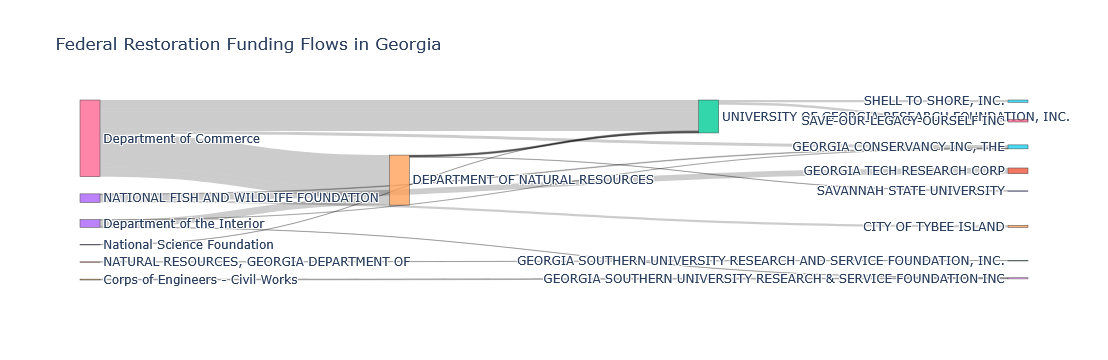

In [20]:
# import plotly.graph_objects as go

# nodes = pd.unique(
#     edges[['source', 'target']].values.ravel()
# )

# node_index = {name: i for i, name in enumerate(nodes)}

# fig = go.Figure(go.Sankey(
#     node=dict(
#         label=nodes
#     ),
#     link=dict(
#         source=edges['source'].map(node_index),
#         target=edges['target'].map(node_index),
#         value=edges['amount']
#     )
# ))

# fig.update_layout(
#     title="Federal Restoration Funding Flows in Georgia"
# )

# fig.show()

In [47]:
# prime_awards = (
#     dfx
#     .groupby("award_id_fain", as_index=False)
#     .agg(
#         federal_obligated=("federal_action_obligation", "sum"),
#         recipient=("recipient_name", "first"),
#         awarding_agency=("awarding_agency_name", "first"),
#         funding_agency=("funding_agency_name", "first"),
#         award_name=("cfda_title", "first"),
#         first_action=("action_date", "min"),
#         last_action=("action_date", "max")
#     )
# )

# subawards = dfy[[
#     "prime_award_fain",
#     "prime_awardee_name",
#     "subawardee_name",
#     "subaward_amount",
#     "subaward_action_date",
#     "subaward_description"
# ]].copy()

# subawards = subawards.rename(columns={
#     "prime_award_fain": "award_id_fain",
#     "prime_awardee_name": "source",
#     "subawardee_name": "target",
#     "subaward_amount": "amount"
# })


# subawards